# Acceptance Rate — AIDev Fix PRs (from `pr_task_type`)

Uses the LLM-classified `pr_task_type.parquet` from AIDev to filter **fix** PRs,
then joins with `pull_request.parquet` to compute acceptance rates for **closed** PRs only.

In [1]:
%pip install pandas pyarrow fsspec requests matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

## Load Data

In [3]:
AIDEV_BASE = "hf://datasets/hao-li/AIDev"

# Load pr_task_type — LLM-classified task types
print("Loading pr_task_type ...")
task_df = pd.read_parquet(f"{AIDEV_BASE}/pr_task_type.parquet")
print(f"  Total rows: {len(task_df):,}")
print(f"  Columns: {list(task_df.columns)}")
print(f"\n  Type distribution:")
print(task_df["type"].value_counts().to_string())

Loading pr_task_type ...


c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Total rows: 33,596
  Columns: ['agent', 'id', 'title', 'reason', 'type', 'confidence']

  Type distribution:
type
feat        14450
fix          8106
docs         3887
test         2356
refactor     2288
chore         896
build         627
ci            411
perf          340
style         188
other          31
revert         16


In [4]:
# Load pull_request table (AIDev-pop) for state & merged_at
print("Loading pull_request ...")
pr_df = pd.read_parquet(f"{AIDEV_BASE}/pull_request.parquet")
print(f"  Total PRs: {len(pr_df):,}")
print(f"  Columns: {list(pr_df.columns)}")

Loading pull_request ...
  Total PRs: 33,596
  Columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']


## Filter Fix PRs & Join with PR State

In [5]:
# Keep only fix-classified PRs
fix_tasks = task_df[task_df["type"] == "fix"].copy()
print(f"Fix PRs in pr_task_type: {len(fix_tasks):,}")

# Join with pull_request to get state & merged_at
fix_prs = fix_tasks.merge(pr_df[["id", "state", "merged_at", "created_at"]], on="id", how="inner")
print(f"Fix PRs after join with pull_request: {len(fix_prs):,}")
print(f"\n  State distribution:")
print(fix_prs["state"].value_counts().to_string())

Fix PRs in pr_task_type: 8,106
Fix PRs after join with pull_request: 8,106

  State distribution:
state
closed    7380
open       726


In [6]:
# Keep only closed PRs
fix_closed = fix_prs[fix_prs["state"] == "closed"].copy()
fix_closed["is_merged"] = fix_closed["merged_at"].notna()

print(f"Closed fix PRs: {len(fix_closed):,}")
print(f"  Merged (accepted):  {fix_closed['is_merged'].sum():,}")
print(f"  Rejected:           {(~fix_closed['is_merged']).sum():,}")

Closed fix PRs: 7,380
  Merged (accepted):  5,267
  Rejected:           2,113


## Acceptance Rate — Overall

In [7]:
total = len(fix_closed)
merged = int(fix_closed["is_merged"].sum())
rejected = total - merged
acceptance_rate = merged / total * 100 if total else 0
rejection_rate = 100 - acceptance_rate

print(f"Overall Acceptance Rate (closed fix PRs):")
print(f"  Accepted (merged):  {merged:,} / {total:,} = {acceptance_rate:.2f}%")
print(f"  Rejected:           {rejected:,} / {total:,} = {rejection_rate:.2f}%")

Overall Acceptance Rate (closed fix PRs):
  Accepted (merged):  5,267 / 7,380 = 71.37%
  Rejected:           2,113 / 7,380 = 28.63%


## Acceptance Rate — Per Agent

In [8]:
agent_rows = []
for agent_name in sorted(fix_closed["agent"].unique()):
    grp = fix_closed[fix_closed["agent"] == agent_name]
    m = int(grp["is_merged"].sum())
    t = len(grp)
    r = m / t * 100 if t else 0
    agent_rows.append({
        "Agent": agent_name,
        "#Accepted": m,
        "#Rejected": t - m,
        "#Total": t,
        "%Acceptance": round(r, 2),
    })
    print(f"  {agent_name:20s}  {m:>6,} / {t:>6,} merged = {r:.1f}%")

agent_df = pd.DataFrame(agent_rows)
display(agent_df)

  Claude_Code               66 /     91 merged = 72.5%
  Copilot                  845 /  1,558 merged = 54.2%
  Cursor                   281 /    365 merged = 77.0%
  Devin                    536 /  1,211 merged = 44.3%
  OpenAI_Codex           3,539 /  4,155 merged = 85.2%


,Agent,#Accepted,#Rejected,#Total,%Acceptance
0,Claude_Code,66,25,91,72.53
1,Copilot,845,713,1558,54.24
2,Cursor,281,84,365,76.99
3,Devin,536,675,1211,44.26
4,OpenAI_Codex,3539,616,4155,85.17


## Visualisation

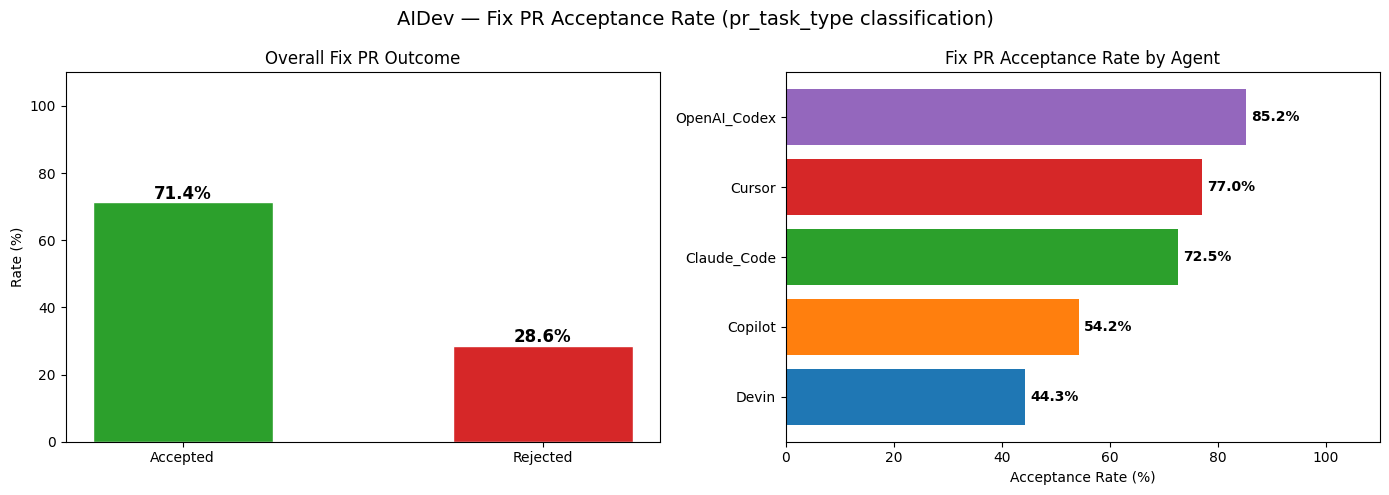

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall acceptance vs rejection
bars = axes[0].bar(["Accepted", "Rejected"], [acceptance_rate, rejection_rate],
                   color=["#2ca02c", "#d62728"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [acceptance_rate, rejection_rate]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Overall Fix PR Outcome")
axes[0].set_ylim(0, 110)

# Right: per-agent acceptance rate
agents_sorted = agent_df.sort_values("%Acceptance", ascending=True)
colors = sns.color_palette("tab10", len(agents_sorted))
bars2 = axes[1].barh(agents_sorted["Agent"], agents_sorted["%Acceptance"], color=colors)
for bar, val in zip(bars2, agents_sorted["%Acceptance"]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Acceptance Rate (%)")
axes[1].set_title("Fix PR Acceptance Rate by Agent")
axes[1].set_xlim(0, 110)

fig.suptitle("AIDev — Fix PR Acceptance Rate (pr_task_type classification)", fontsize=14)
fig.tight_layout()
plt.show()

## Summary Table with Median Time to Merge

In [10]:
def compute_row(label, df):
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged_subset = df[df["merged_at"].notna()].copy()
    if len(merged_subset):
        merged_subset["hours"] = (
            pd.to_datetime(merged_subset["merged_at"], utc=True)
            - pd.to_datetime(merged_subset["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged_subset["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}h"]


rows = [compute_row("All Agents", fix_closed)]
for agent_name in sorted(fix_closed["agent"].unique()):
    rows.append(compute_row(f"  {agent_name}", fix_closed[fix_closed["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
display(summary_df)

,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,All Agents,"5,267","2,113","7,380",71.4%,0.11h
1,Claude_Code,66,25,91,72.5%,0.60h
2,Copilot,845,713,"1,558",54.2%,18.11h
3,Cursor,281,84,365,77.0%,0.30h
4,Devin,536,675,"1,211",44.3%,1.36h
5,OpenAI_Codex,"3,539",616,"4,155",85.2%,0.02h
